# 2.5 Radar Recognition (part 2)

## Import Libraries and Datasets

In [15]:
pip install tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 MB 15.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 17.2 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 16.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 15.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 15.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.4/634.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [tensorflow]6 [tensorflow]]]
Note: you may need to restart the kernel to use updated packages.


In [27]:
# ========================
# 🔧 Core Python Tools
# ========================
import os  # File and path handling
import numpy as np  # Arrays, math operations
from PIL import Image  # For image loading and processing

# ========================
# 📊 Visualization
# ========================
import matplotlib.pyplot as plt  # To show images and plots
import seaborn as sns  # Optional — for heatmaps, visual aesthetics

# ========================
# 🤖 Machine Learning Tools
# ========================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score  # Model evaluation

# ========================
# 🧠 Neural Network Libraries
# ========================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model



In [9]:
#download the weather images and put them in a directory
path = '/Users/amyzhang/Desktop/CF_ML_ClimateWins/Multi-class Weather Dataset'
folders = os.listdir(path)
print(folders)

['Cloudy', 'Rain', 'Shine', 'Sunrise']


In [19]:
#this will load in the pictures and rescale them to 250x250pixels

datagenerator = ImageDataGenerator(rescale=1/255, validation_split=0.2)
train_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='training',
)

test_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='validation',
)

Found 901 images belonging to 4 classes.
Found 224 images belonging to 4 classes.


## Build the CNN Model Architecture for Weather Image Classification
This section defines a Convolutional Neural Network (CNN) using the Functional API, tailored to classify weather images into 4 categories based on features extracted from 250×250 RGB images.

In [29]:
#this is a CNN to categorize the weather images

inputs = Input(shape=(250, 250, 3))

x = Conv2D(32, (5,5), activation = 'relu')(inputs)
x = MaxPooling2D(3,3)(x)
x = Conv2D(64, (5,5) , activation = 'relu')(x)
x = MaxPooling2D((3,3))(x)
x = Conv2D(128 , (5,5) , activation = 'relu')(x)
x = MaxPooling2D(3,3)(x)
x = Flatten()(x)
x = Dropout(0.5, seed = 5)(x)
x = Dense(128 , activation = 'relu')(x)

outputs = Dense(4, activation = 'softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

## 🚦 Change Loss Function from MSE to Categorical Cross-Entropy

* **Mean Squared Error (MSE)** is appropriate for regression tasks, where we care about the distance between predicted and actual values. But in classification, using MSE means treating probability errors like distance errors, which ignores the log-based nature of confidence in class predictions.
* **Categorical Cross-Entropy** is the correct choice here because:

  * We have **more than two possible classes** (i.e., it's not a binary classification problem).
  * Each input belongs to **exactly one class**, and we want the model to predict the **single most likely class**.
* Binary cross-entropy would only be appropriate if this were a **binary or multi-label** problem.


In [37]:
#compile and run the model
#how many epochs are required to generate an accurate model?

### ⚠️ Replaced "MSE" with "categorical cross-entropy" for loss-function. This is a categorical problem, not a continuous output. 
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    train_generator,
    epochs=10,  # ← Try 10-20 epochs depending on performance
    steps_per_epoch=train_generator.n // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.n // test_generator.batch_size,
)


Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6158 - loss: 0.8031 - val_accuracy: 0.7143 - val_loss: 0.6528
Epoch 2/10
 1/28 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.7812 - loss: 0.5012

/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.7812 - loss: 0.5012 - val_accuracy: 0.7098 - val_loss: 0.6386
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7278 - loss: 0.5801 - val_accuracy: 0.7098 - val_loss: 0.8201
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.8000 - loss: 0.3932 - val_accuracy: 0.7054 - val_loss: 0.7511
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.7792 - loss: 0.5806 - val_accuracy: 0.7768 - val_loss: 0.6063
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - accuracy: 0.7500 - loss: 0.3960 - val_accuracy: 0.8304 - val_loss: 0.4787
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8410 - loss: 0.4089 - val_accuracy: 0.7679 - val_loss: 0.6100
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step - accuracy: 0.8438 - loss: 0.3858 - val_accuracy: 0.7634 - val_loss: 0.6145
Epoch 9/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.8395 - loss: 0.4090 - val_accuracy: 0.8259 - val_loss: 0.

## Evaluate the CNN Model

In [39]:
results = pd.DataFrame(model.history.history)

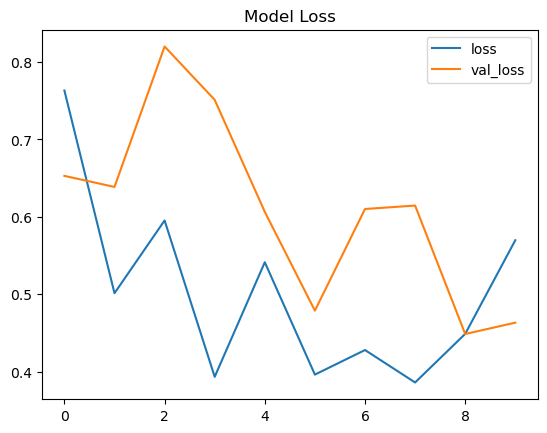

In [56]:
results[['loss','val_loss']].plot(title='Model Loss')
plt.savefig('./loss.png')

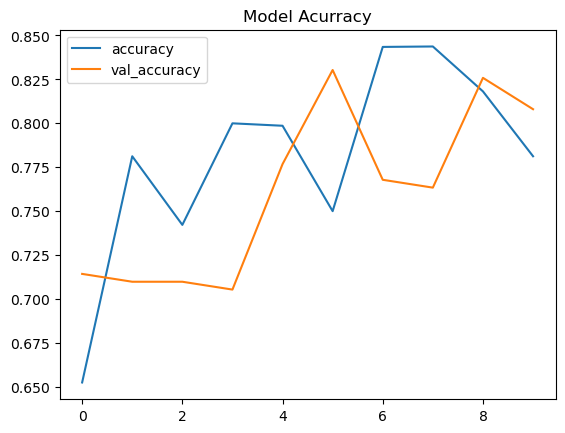

In [43]:
results[['accuracy','val_accuracy']].plot(title='Model Acurracy')
plt.savefig('./accuracy.png')

In [45]:
# Print the accuracy and loss
print("Accuracy: {}, Val_Accuracy: {}".format(results['accuracy'].iloc[-1], results['val_accuracy'].iloc[-1]))
print("Loss: {}, Val_Loss: {}".format(results['loss'].iloc[-1], results['val_loss'].iloc[-1]))

Accuracy: 0.78125, Val_Accuracy: 0.8080357313156128
Loss: 0.5696542263031006, Val_Loss: 0.4631505012512207


## 📈 Model Loss and Accuracy Curve Analysis

* Both **training and validation loss curves are erratic and spiky**, indicating the model is **struggling to converge smoothly**. This kind of instability often signals issues such as a **too-high learning rate**, **noisy or insufficient data**, or an **architecture that doesn’t fully fit the problem yet**.

* Despite the noise, there is an **overall downward trend in loss**, showing the model is learning initially. However, from epochs 7–10, the **loss starts increasing again on both training and validation sets**, which strongly suggests **overfitting** — the model begins **memorizing training data** instead of generalizing.

* The **validation loss is generally higher than the training loss**, as expected, but the brief dip below training loss around epoch 8 is likely a minor fluctuation rather than a stable pattern.

* For accuracy, the **validation accuracy surpasses training accuracy at some points**, which can happen due to factors like **dropout/batch normalization behaving differently during evaluation** or smaller, easier validation batches. This is a reminder that **metrics can sometimes be noisy or counterintuitive**, especially on smaller datasets.

* Towards the end of training (epochs 8–10), **both accuracy and loss degrade on training and validation**, indicating the model is **overfitting** or experiencing **optimization instability** — possibly due to an **inappropriate learning rate** or hitting a **local minima/plateau** in training.

---

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 328ms/step


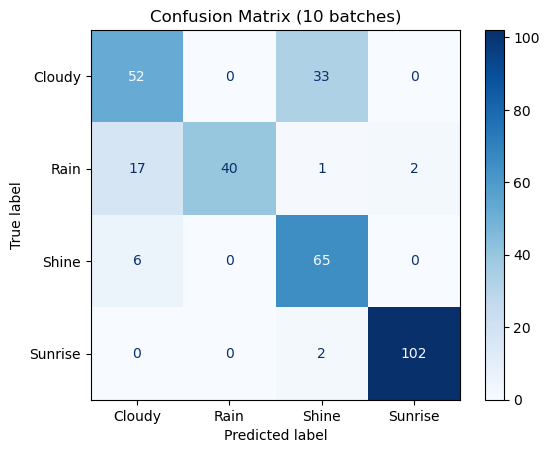

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def plot_confusion_matrix(model, test_generator, class_names, n_batches=10):
    # Collect n batches of images and labels
    image_batch, classes_batch = next(test_generator)
    for _ in range(n_batches - 1):  # already have 1 batch, so do n-1 more
        temp_images, temp_labels = next(test_generator)
        image_batch = np.concatenate((image_batch, temp_images))
        classes_batch = np.concatenate((classes_batch, temp_labels))

    # Predict classes
    y_pred_probs = model.predict(image_batch)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(classes_batch, axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix with labels
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix ({n_batches} batches)")
    plt.show()

# Usage example:
class_names = ['Cloudy', 'Rain', 'Shine', 'Sunrise']
plot_confusion_matrix(model, test_generator, class_names, n_batches=10)


## Confusion Matrix -- observations

* **Shine vs. Sunrise:** It’s interesting that Shine images are never confused for Sunrise, but Sunrise occasionally gets misclassified as Shine. That might hint that Shine images have more distinct features the model can latch onto.

* **Cloudy confused for Shine (not Rain):** Maybe the model struggles with subtle brightness or color differences between Cloudy and Shine but finds Rain’s texture/rain patterns easier to identify. Could be that the brightness contrast in the images is misleading it — Cloudy images might sometimes have lighting that’s closer to Shine than to Rain, or the rain visuals are distinct enough to separate out.

* **High false predictions in Cloudy:** The balance of true positives and false positives in Cloudy suggests it’s a challenging category. This often means the model’s feature extraction can’t reliably isolate Cloudy from other classes. The dataset has overlapping features or noise.

### **(ChatGPT recommendations)** 
"This kind of confusion often points to where you might want to:

* Collect more **diverse samples** for Cloudy to teach the model better distinctions
* Explore **data augmentation** that simulates varying lighting conditions
* Maybe add or fine-tune **preprocessing** (like histogram equalization) to highlight texture or shading cues
* Check if your model architecture or hyperparameters can better capture subtle differences (maybe try a deeper model or different kernel sizes)"


In [49]:
#This function will display a number of random images as well as the predictions for the type of weather.

def predict_one(model, num_images = None):  
    image_batch, classes_batch = next(test_generator)
    predicted_batch = model.predict(image_batch)
    for k in range(0,image_batch.shape[0] if num_images is None else num_images):
        image = image_batch[k]
        real_class = class_names[np.argmax(classes_batch[k])]
        predicted_class = class_names[np.argmax(predicted_batch[k])]
        value_predicted = predicted_batch[k]
        isTrue = (real_class == predicted_class)
        plt.figure(k)
        plt.title(str("Correct Prediction" if isTrue else "Incorrect Prediction") + ' - class: ' + real_class + ' - ' + 'predicted: ' + predicted_class + str(value_predicted))
        plt.axis('off')
        plt.savefig('./' + real_class + '_' + predicted_class + '_' + str(value_predicted) + '.png')
        plt.imshow(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step


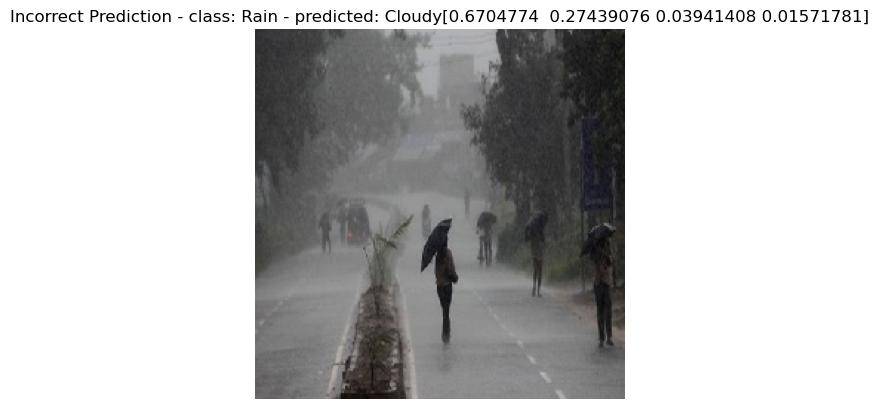

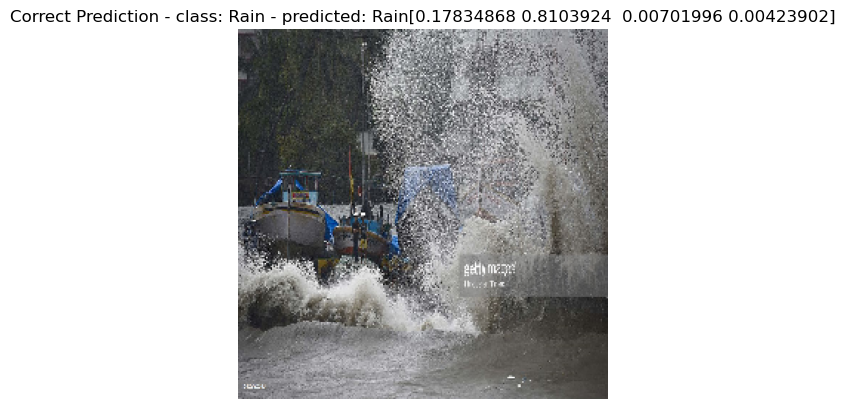

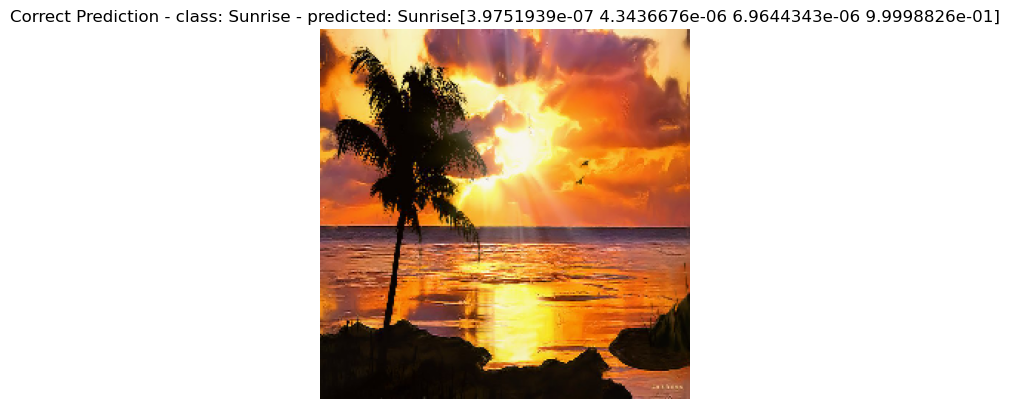

In [51]:
predict_one(model, 3) #<--you can show multiple pictures with this command. Just fill in the number you want to see.